In [1]:
!pip install pandas numpy seaborn matplotlib scipy pydeseq2 gprofiler adjustText
!git clone https://github.com/simonelsasser/SP1-01-Ex.git
%cd "SP1-01-Ex/Kumar_NCB"
!ls Data

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 100.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 7.4 MB/s eta 0:00:00
Cloning into 'SP1-01-Ex'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 30 (delta 6), reused 28 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 4.42 MiB | 23.19 MiB/s, done.
Resolving deltas: 100% (6/6), done.
/content/SP1-01-Ex/Kumar_NCB
gene_group_mapping.csv	metaData.csv  rsem.merged.gene_counts_2021.tsv


In [3]:
import pandas as pd
import numpy as np

#########################
######   TASK 1   #######
#      read in data     #
#########################

file_path = "Data/rsem.merged.gene_counts_2021.tsv"
# Read in count file "Data/rsem.merged.gene_counts_2021.tsv", it is a tab-separated file with the first column as index
count_table = pd.read_csv(file_path, sep='\t', index_col=0)
# Print the first 5 rows of the count table
print(count_table.head())

                                           transcript_id(s)  Naive_EZH2i_R1  \
gene_id                                                                       
A1BG                                              NM_130786             3.0   
A1BG-AS1                                          NR_015380             7.0   
A1CF      NM_001198818,NM_001198819,NM_001198820,NM_0145...             0.0   
A2M                                               NM_000014             1.0   
A2M-AS1                                           NR_026971             0.0   

          Naive_EZH2i_R2  Naive_EZH2i_R3  Naive_R1  Naive_R2  Naive_R3  \
gene_id                                                                  
A1BG                 4.0             6.0       2.0       0.0       4.0   
A1BG-AS1             4.0             5.0       2.0       3.0       2.0   
A1CF                 0.0             0.0       0.0       0.0       0.0   
A2M                  1.0             1.0       0.0       0.0       0.0   
A2

In [4]:

# we are going to remove 'transcript_id(s)' from the count table, as they are not needed for the analysis
count_table = count_table.drop('transcript_id(s)', axis=1)
# Print the head again
print(count_table.head())


          Naive_EZH2i_R1  Naive_EZH2i_R2  Naive_EZH2i_R3  Naive_R1  Naive_R2  \
gene_id                                                                        
A1BG                 3.0             4.0             6.0       2.0       0.0   
A1BG-AS1             7.0             4.0             5.0       2.0       3.0   
A1CF                 0.0             0.0             0.0       0.0       0.0   
A2M                  1.0             1.0             1.0       0.0       0.0   
A2M-AS1              0.0             0.0             0.0       0.0       0.0   

          Naive_R3  Primed_EZH2i_R1  Primed_EZH2i_R2  Primed_EZH2i_R3  \
gene_id                                                                 
A1BG           4.0            137.0            175.0            143.0   
A1BG-AS1       2.0             36.0             28.0             28.0   
A1CF           0.0              2.0              0.0              0.0   
A2M            0.0            143.0            114.0            112.0   
A

In [20]:
#Check the numbers in the count table - it looks like they are all intergers. Is this what you expect?

#Let's take the first column (Naive_EZH2i_R1)- What is the min, max, mean, median and variance of the counts in the count table? 
print("Min:", count_table.iloc[:, 0].min())
print("Max:", count_table.iloc[:, 0].max())
print("Mean:", count_table.iloc[:, 0].mean())
print("Median:", np.median(count_table.iloc[:, 0]))
print("Variance:", np.var(count_table.iloc[:, 0]))
print("Number of zeros:", np.sum(count_table.iloc[:, 0] == 0))

# Are there any zeros? How many genes in total and how many genes have zero counts in all samples?
print("Total number of genes:", count_table.shape[0])
print("Number of genes with zero counts in all samples:", np.sum(np.all(count_table.values == 0, axis=1)))

Min: 0.0
Max: 76778.0
Mean: 84.87063229461758
Median: 3.0
Variance: 379818.61545530043
Number of zeros: 10968
Total number of genes: 26475
Number of genes with zero counts in all samples: 6044


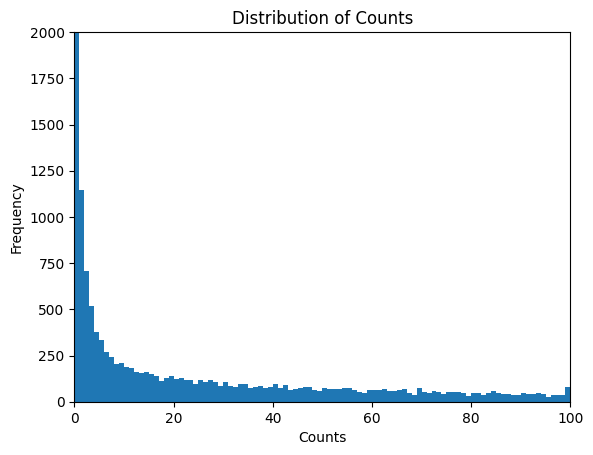

In [18]:

# What is the distribution of counts? Can you make a graph to inspect the distribution? 
import matplotlib.pyplot as plt

# Plot a histogram of the counts in the first column, limit the x axis to 0-100 and set the bin width to 10
# What do you observe? What does the high peak at zero and long tail mean?
plt.hist(count_table.iloc[:, 0], bins=100, range=(0, 100))
plt.xlabel('Counts')
plt.ylabel('Frequency')
plt.title('Distribution of Counts')
plt.xlim(0, 100)
plt.ylim(0, 2000)
plt.show()

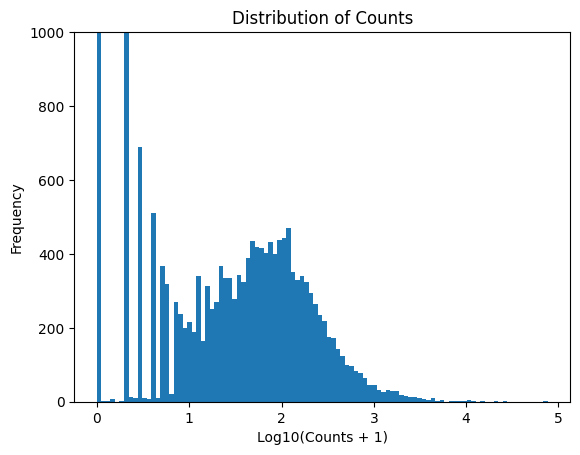

In [38]:
# Let's try to log transform the counts with log10 (add + 1 to the count table to avoid log(0)!)
plt.hist(np.log10(count_table.iloc[:, 0]+1), bins=100)
plt.xlabel('Log10(Counts + 1)')
plt.ylabel('Frequency')
plt.title('Distribution of Counts')
plt.ylim(0, 1000)
plt.show()

In [39]:
# For comparing gene expression, we need to understand the distribution of read counts not within one sample, but for each gene across all samples. Let's plot the distribution of counts the pluripotency factor gene NANOG and GAPDH (housekeeping gene)across all samples. What do you observe?
print(count_table.loc['NANOG', :])
print(count_table.loc['GAPDH', :])


Naive_EZH2i_R1      103.0
Naive_EZH2i_R2       82.0
Naive_EZH2i_R3       79.0
Naive_R1            778.0
Naive_R2            770.0
Naive_R3            804.0
Primed_EZH2i_R1    1541.0
Primed_EZH2i_R2    1418.0
Primed_EZH2i_R3    1411.0
Primed_R1          1214.0
Primed_R2          1124.0
Primed_R3          1183.0
Name: NANOG, dtype: float64
Naive_EZH2i_R1       8707.0
Naive_EZH2i_R2       9111.0
Naive_EZH2i_R3       8525.0
Naive_R1            10536.0
Naive_R2             9876.0
Naive_R3            10762.0
Primed_EZH2i_R1    111974.0
Primed_EZH2i_R2    125424.0
Primed_EZH2i_R3    102649.0
Primed_R1          111263.0
Primed_R2          111576.0
Primed_R3          125533.0
Name: GAPDH, dtype: float64


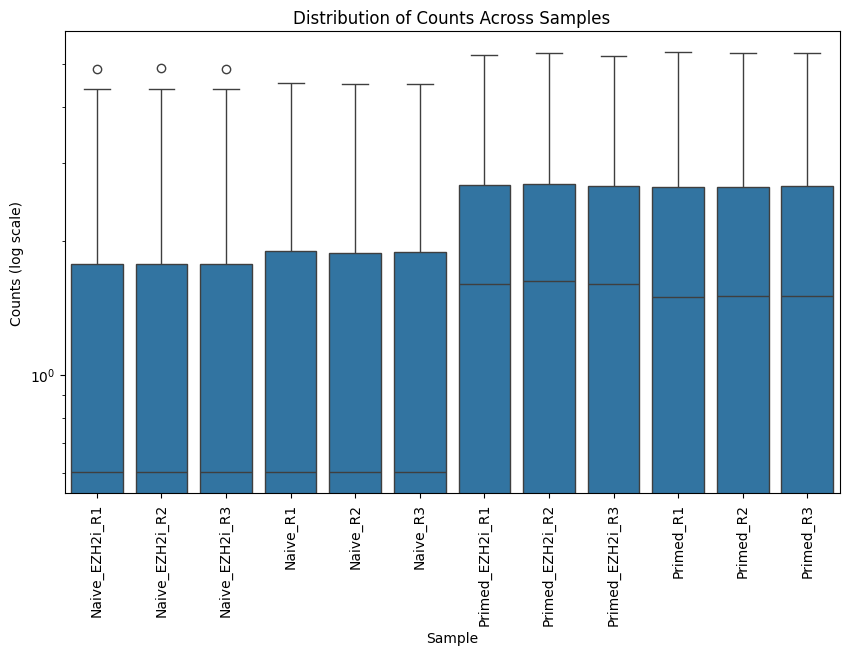

In [45]:
# Now something looks strange - the counts for "Primed" appear to be much higher even for housekeeping gene GAPDH. Let's plot the distribution of counts for all samples and see if we can spot any batch effect or other technical bias. We can use a box plot for this.
import seaborn as sns
# Convert the count table to long format for seaborn box plot and log transform
count_table_long = count_table.melt(var_name='Sample', value_name='Count')
count_table_long['Count'] = np.log10(count_table_long['Count'] + 1)
# Plot a box plot of counts for each sample
plt.figure(figsize=(10, 6))
sns.boxplot(x='Sample', y='Count', data=count_table_long)
plt.yscale('log')
plt.xlabel('Sample')
plt.ylabel('Counts (log scale)')
plt.title('Distribution of Counts Across Samples')
plt.xticks(rotation=90)
plt.show()

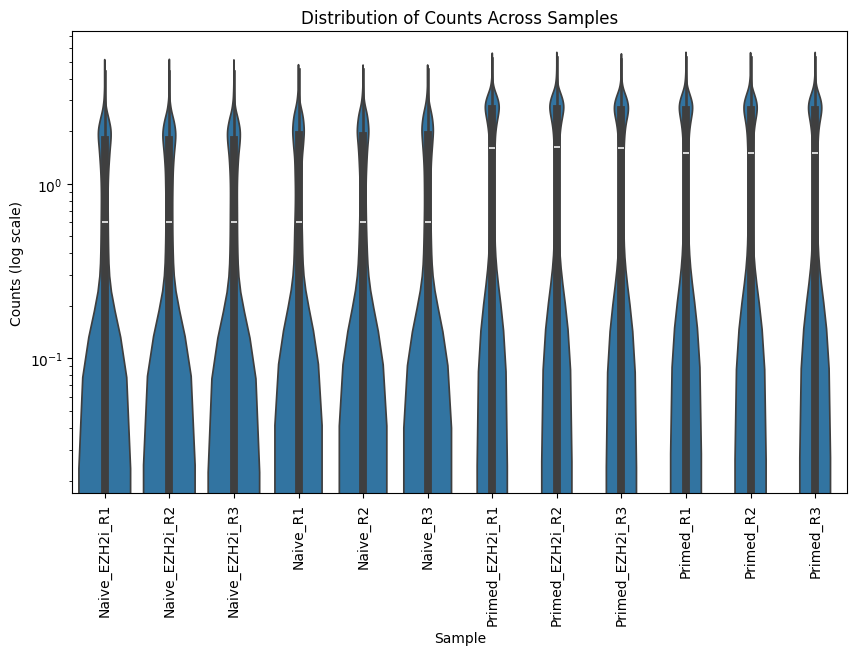

In [46]:

# Since we learned that boxplots could hide the distribution of the data, let's try a violin plot instead
# Plot a violin plot of counts for each sample
plt.figure(figsize=(10, 6))
sns.violinplot(x='Sample', y='Count', data=count_table_long)
plt.yscale('log')
plt.xlabel('Sample')
plt.ylabel('Counts (log scale)')
plt.title('Distribution of Counts Across Samples')
plt.xticks(rotation=90)
plt.show()

In [52]:
# Clearly there is a big difference between the "Naive" and "Primed" samples
# A trivial source of this difference is that libraries are sequenced to different depths, this happens because it is difficult to exactly normalize the NGS library
# before sequencing
# In the current dataset, the BGI generated almost exactly the same sequencing depth. But we actually know why there is a sytematic different:
# The "Naive" cells are grown on mouse feader cells, so in the RNA extraction
# we have a big contribution of mouse RNA, this will be part of the library but it will not map to the human genome. So a lot of the reads in the library are 'lost' to mouse RNA,
# and as a result we appear to have less total reads.

# In order to compare gene expression between the "Naive" and "Primed" samples, we need to normalize the counts to account for this difference in sequencing depth. One common way to do this is to calculate counts per million (CPM) or transcripts per million (TPM). Let's calculate CPM for each sample and plot the distribution again.
# Calculate CPM: Normalize each row count by the total read count of the sample (column sum) and multiply by 1 million
cpm_table = count_table.div(count_table.sum(axis=0), axis=1) * 1e6
# now check NANOG and GAPDH again
print(cpm_table.loc['NANOG', :])
print(cpm_table.loc['GAPDH', :])

Naive_EZH2i_R1      45.839917
Naive_EZH2i_R2      36.234815
Naive_EZH2i_R3      35.005953
Naive_R1           250.617446
Naive_R2           253.871128
Naive_R3           256.065715
Primed_EZH2i_R1    103.559824
Primed_EZH2i_R2     90.107487
Primed_EZH2i_R3     98.619887
Primed_R1           81.683712
Primed_R2           75.276751
Primed_R3           77.185017
Name: NANOG, dtype: float64
Naive_EZH2i_R1     3875.030614
Naive_EZH2i_R2     4026.041502
Naive_EZH2i_R3     3777.541155
Naive_R1           3393.965822
Naive_R2           3256.144498
Naive_R3           3427.586102
Primed_EZH2i_R1    7524.988819
Primed_EZH2i_R2    7970.128003
Primed_EZH2i_R3    7174.509404
Primed_R1          7486.305485
Primed_R2          7472.490013
Primed_R3          8190.419876
Name: GAPDH, dtype: float64


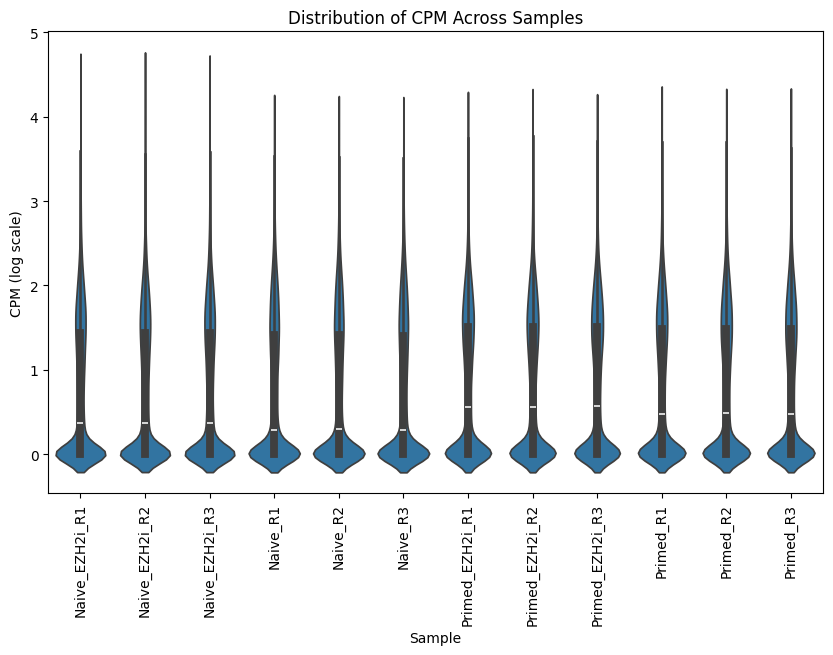

In [53]:

# Convert to long format for plotting and log transform 
cpm_table_long = cpm_table.melt(var_name='Sample', value_name='CPM')
cpm_table_long['CPM'] = np.log10(cpm_table_long['CPM'] + 1)
# Plot a violin plot of CPM for each sample
plt.figure(figsize=(10, 6))
sns.violinplot(x='Sample', y='CPM', data=cpm_table_long)
plt.xlabel('Sample')
plt.ylabel('CPM (log scale)')
plt.title('Distribution of CPM Across Samples')
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Great, now the "Naive" and "Primed" samples look much more similar, we can now compare gene expression between them!
### WARNING: CPM is not a good normalization method for differential expression analysis, because it is highly skewed by the largest counts in the table (the tail)
# Better would be to align the distributions, e.g. by minimizing the variance of the log fold changes between samples, this is what DESeq2 does with its size factor estimation. We will learn about this in the next session.
# But you can see that for now CPM works quite OK for the given data

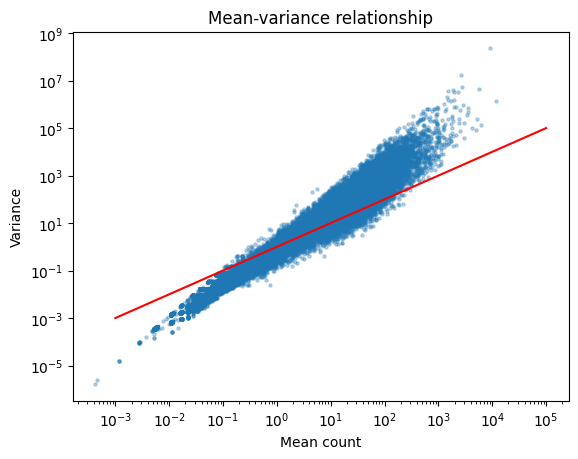

In [56]:
## DESeq2 works under the assumption of a negative binomial distribution, which means that the variance should be higher than the mean. 
# This is an empirical observation that holds for most genes in RNA-seq data, and it is one of the reasons why DESeq2 uses a negative binomial distribution to model the counts.
# The alternative model wpuld be the Poisson distribution, which assumes that the variance is equal to the mean. 
# Let's check if this is true for our data by plotting the mean-variance relationship of the CPM values.
means = cpm_table.mean(axis=1)
vars_ = cpm_table.var(axis=1)

plt.scatter(means, vars_, s=5, alpha=0.3)
plt.xscale("log")
plt.yscale("log")

plt.xlabel("Mean count")
plt.ylabel("Variance")
plt.title("Mean-variance relationship")
x = np.logspace(-3, 5, 100)
plt.plot(x, x, color="red", label="Poisson variance")
plt.show()


In [57]:
# Read in clinical data file / annotation 
file_path_cl = "Data/metaData.csv"

# Read in file 
experiment_design = pd.read_csv(file_path_cl, sep=",")

# Get an overview of the file
print(experiment_design.head())

      BioSample          SRR       condition              treatment  \
0  SAMN25076933  SRR17657871  naive (t2iGoY)                   none   
1  SAMN25076934  SRR17657872  naive (t2iGoY)                   none   
2  SAMN25076935  SRR17657873  naive (t2iGoY)                   none   
3  SAMN25076936  SRR17657874  naive (t2iGoY)  10 uM EZH2 for 7 days   
4  SAMN25076938  SRR17657875  naive (t2iGoY)  10 uM EZH2 for 7 days   

             Name  
0        Naive_R1  
1        Naive_R2  
2        Naive_R3  
3  Naive_EZH2i_R1  
4  Naive_EZH2i_R2  


In [58]:
#########################
######   TASK 2   #######
# Preparation for DESeq #
#########################

# prepare count table 
# filter for lowly expressed genes
genes_to_keep = count_table.columns[count_table.sum(axis=0) >= 10]
counts_df = count_table[genes_to_keep]

# convert dataframe to integer
counts_df = counts_df.astype(int)

# transpose dataframe for Deseq analysis
counts_df = counts_df.T

counts_df.head()

gene_id,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2MP1,A3GALT2,A4GALT,A4GNT,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
Naive_EZH2i_R1,3,7,0,1,0,10,0,0,317,0,...,81,137,12,53,89,38,116,919,186,106
Naive_EZH2i_R2,4,4,0,1,0,10,0,0,303,0,...,101,135,10,34,107,34,99,865,192,94
Naive_EZH2i_R3,6,5,0,1,0,16,0,0,279,0,...,95,146,7,39,99,37,115,767,204,107
Naive_R1,2,2,0,0,0,7,0,0,1072,0,...,158,235,15,146,150,213,144,1193,332,199
Naive_R2,0,3,0,0,0,6,0,0,1045,0,...,133,229,19,147,176,233,137,1093,306,173


In [61]:
# prepare metaData
# shape meta for DESeq analysis (name as index, treatment as column)
meta = experiment_design.set_index("Name")
meta = meta[["treatment"]]
print(meta)

#count_naive = count_table[naive_samples]
#count_naive = count_naive.astype(int)
#count_naive = count_naive[~count_naive.index.duplicated(keep="first")]
#count_naive

                             treatment
Name                                  
Naive_R1                          none
Naive_R2                          none
Naive_R3                          none
Naive_EZH2i_R1   10 uM EZH2 for 7 days
Naive_EZH2i_R2   10 uM EZH2 for 7 days
Naive_EZH2i_R3   10 uM EZH2 for 7 days
Primed_R1                         none
Primed_R2                         none
Primed_R3                         none
Primed_EZH2i_R1  10 uM EZH2 for 7 days
Primed_EZH2i_R2  10 uM EZH2 for 7 days
Primed_EZH2i_R3  10 uM EZH2 for 7 days


In [69]:
##print("counts_df samples:")
print(counts_df.index.tolist())
print("\nmeta samples:")
print(meta.index.tolist())
print("\nDo they match?")
print(set(counts_df.index) == set(meta.index))#######################
######   TASK 3   #######
#     Running DESeq2    #
#########################

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# create DeseqDataSet
dds = DeseqDataSet(
    counts=counts_df,
    metadata=meta,
    design="~treatment",
    refit_cooks=True)


['Naive_EZH2i_R1', 'Naive_EZH2i_R2', 'Naive_EZH2i_R3', 'Naive_R1', 'Naive_R2', 'Naive_R3', 'Primed_EZH2i_R1', 'Primed_EZH2i_R2', 'Primed_EZH2i_R3', 'Primed_R1', 'Primed_R2', 'Primed_R3']

meta samples:
['Naive_R1', 'Naive_R2', 'Naive_R3', 'Naive_EZH2i_R1', 'Naive_EZH2i_R2', 'Naive_EZH2i_R3', 'Primed_R1', 'Primed_R2', 'Primed_R3', 'Primed_EZH2i_R1', 'Primed_EZH2i_R2', 'Primed_EZH2i_R3']

Do they match?
True


ValueError: Index of obs must match index of X.

In [7]:
# run dds.deseq2()
dds.deseq2()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 12.68 seconds.

Fitting dispersion trend curve...
... done in 0.33 seconds.

Fitting MAP dispersions...
... done in 14.30 seconds.

Fitting LFCs...
... done in 9.37 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



In [8]:
# calculate DESeqStats and summary
ds = DeseqStats(dds, contrast=["treatment", "10 uM EZH2 for 7 days", "none"],n_cpus=1)

# get ds summary overview
ds.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: treatment 10 uM EZH2 for 7 days vs none
             baseMean  log2FoldChange     lfcSE       stat        pvalue  \
gene_id                                                                    
A1BG         3.385463        1.627342  1.100425   1.478831  1.391854e-01   
A1BG-AS1     4.128906        1.701937  0.961590   1.769920  7.674053e-02   
A1CF         0.000000             NaN       NaN        NaN           NaN   
A2M          0.591524        2.952533  2.895491   1.019700  3.078707e-01   
A2M-AS1      0.000000             NaN       NaN        NaN           NaN   
...               ...             ...       ...        ...           ...   
ZYG11A     112.932390       -2.088826  0.207425 -10.070263  7.477808e-24   
ZYG11B     121.141407        0.214549  0.176300   1.216955  2.236213e-01   
ZYX       1005.964972        0.001137  0.090138   0.012609  9.899393e-01   
ZZEF1      251.495668       -0.253481  0.126232  -2.008053  4.463763e-02   
ZZZ3      

... done in 3.40 seconds.



In [9]:
#########################
######   TASK 4   #######
#    volcanoe plot      #
#########################

# get results in object
res = ds.results_df
res_sorted = res.sort_values(by="padj")
print(res_sorted)


                baseMean  log2FoldChange     lfcSE       stat    pvalue  padj
gene_id                                                                      
IGFBP3        876.172760        5.223203  0.132881  39.307464  0.000000   0.0
COL1A2       3008.467372        3.039702  0.060405  50.322098  0.000000   0.0
COL6A2       2184.715219        3.054435  0.069622  43.871688  0.000000   0.0
COL6A1       3512.899380        2.416379  0.060187  40.147798  0.000000   0.0
COL4A2       2063.172371        3.025194  0.069693  43.407649  0.000000   0.0
...                  ...             ...       ...        ...       ...   ...
ZSCAN1          0.693945       -2.672557  2.898481  -0.922055  0.356500   NaN
ZSCAN16-AS1     1.754305       -0.296782  1.405774  -0.211116  0.832796   NaN
ZSCAN23         0.745381       -1.374524  2.415369  -0.569074  0.569306   NaN
ZSCAN5B         1.138501        0.097533  1.812209   0.053820  0.957078   NaN
ZSWIM2          0.000000             NaN       NaN        NaN   

In [10]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

# genes to mark as in volcanoe plot
genes_to_mark =  ["KRT18",  "H19", "IGF2", "EPAS2", "COL6A3", "MME",
    "VIM", "MMP2", "EGFL6", "CCKBR", "GATA2", "COL15A1", "CD99","EPAS1",
    "LAMB1", "THBD", "FRZB",  "RELN", "TDGF1", "MT1G","DDPA5","NODAL","NANOG","UTF1",
    "FGF4"]



# create volcanoe_df for plotting
volcanoe_df = res_sorted.copy()

# remove possible missing values and filter for log2FC and padj
volcanoe_df = volcanoe_df.dropna(subset=["log2FoldChange", "padj"])


# replace "0" padj and calculate -log10
volcanoe_df["padj"] = volcanoe_df["padj"].replace(0, 1e-300)
volcanoe_df["neg_log10_padj"] = -np.log10(volcanoe_df["padj"])


# read in color mapping (groups of genes)
file_path = "Data/gene_group_mapping.csv"
color_annotation = pd.read_csv(file_path, sep=',', index_col=0)

# colors similar to figure 
color_map = {
    "Always_up": "navy",
    "Ni_higher_than_Pr": "#008B8B",
    "Pr_higher_than_Ni": "#A52A2A"
}


# delete duplicated entries in volcanoe_df and color_annotation
volcanoe_df = volcanoe_df[~volcanoe_df.index.duplicated(keep="first")]
color_annotation = color_annotation[~color_annotation.index.duplicated(keep="first")]

# map group and color to volcanoe_dj
volcanoe_df["group"] = color_annotation["group"].reindex(volcanoe_df.index)
volcanoe_df["color"] = volcanoe_df["group"].map(color_map)

# set all other colors to darkgrey
volcanoe_df["color"] = volcanoe_df["color"].fillna("darkgrey")

# get subsets of data sets for plotting
subsetNon = volcanoe_df[volcanoe_df["group"] == "Non bivalent"]
subsetUp = volcanoe_df[volcanoe_df["group"] == "Always_up"]
subsetNi = volcanoe_df[volcanoe_df["group"] == "Ni_higher_than_Pr"]
subsetPr = volcanoe_df[volcanoe_df["group"] == "Pr_higher_than_Ni"]

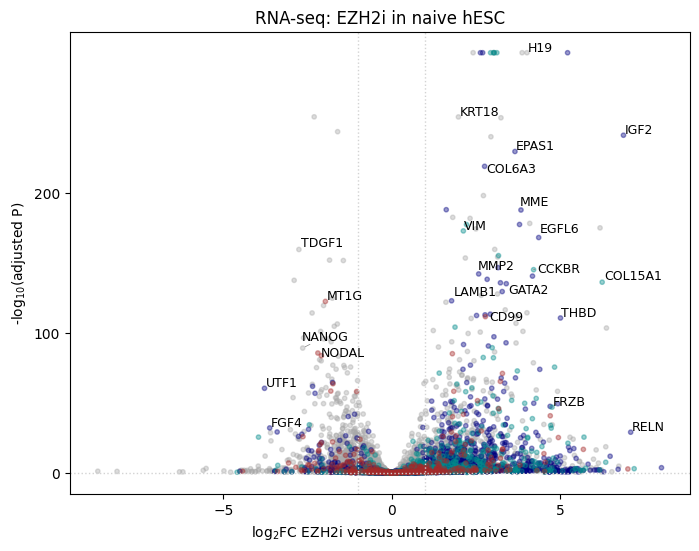

In [11]:

plt.figure(figsize=(8,6))

# background
plt.scatter(
    subsetNon["log2FoldChange"],
    subsetNon["neg_log10_padj"],
    s=10,
    color=subsetNon["color"],
    alpha=0.4,
    zorder=0
)

# blue points
plt.scatter(
    subsetUp["log2FoldChange"],
    subsetUp["neg_log10_padj"],
    s=10,
    color=subsetUp["color"],
    alpha=0.4,
    zorder=0
)


# cyan points
plt.scatter(
    subsetNi["log2FoldChange"],
    subsetNi["neg_log10_padj"],
    s=10,
    color=subsetNi["color"],
    alpha=0.4,
    zorder=0
)


# red points
plt.scatter(
    subsetPr["log2FoldChange"],
    subsetPr["neg_log10_padj"],
    s=10,
    color=subsetPr["color"],
    alpha=0.4,
    zorder=0
)

# get texts for each gene to mark
texts = []
for gene in genes_to_mark:
    if gene in volcanoe_df.index:
        x = volcanoe_df.loc[gene, "log2FoldChange"]
        y = volcanoe_df.loc[gene, "neg_log10_padj"]

        texts.append(
            plt.text(x, y, gene, fontsize=9)
        )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5)
)

plt.xlabel(r"log$_2$FC EZH2i versus untreated naive")
plt.ylabel(r"-log$_{10}$(adjusted P)")
plt.title("RNA-seq: EZH2i in naive hESC")
plt.xticks([-5,0,5])
plt.yticks([0,100,200])
plt.axhline(y=0, color="lightgrey", linestyle=":", linewidth=1)
plt.axvline(x=-1, color="lightgrey", linestyle=":", linewidth=1)
plt.axvline(x=1, color="lightgrey", linestyle=":", linewidth=1)
plt.show()